# 📊 Tourism Motivation Analysis - Clean 5-Category Pie Chart

**Ultra-fast parallel processing** for 25+ million records with focused 5-category motivation analysis.

### Features:
- 🚀 **Parallel Processing**: Multi-core data loading and analysis
- 🗄️ **Intelligent Caching**: Avoid reprocessing previously analyzed files
- 📊 **Clean Pie Chart**: Focus on motivation percentages only
- 📤 **Canva Export**: CSV export optimized for presentation import
- ⚡ **Memory Optimized**: Chunked processing for large datasets
- 🎯 **5 Essential Categories**: Simplified and focused analysis
- 📍 **No Fake Data**: Real data processing only

### 5 Essential Motivation Categories:
1. **Per Esclusione** - Decisions based on exclusion/filtering logic
2. **Ragionamento Geospaziale** - Spatial proximity and geographic reasoning
3. **Ragionamento Temporale** - Time-based and temporal optimization
4. **Per Popolarità** - Popularity and destination appeal
5. **Thematic Continuity** - Thematic and cultural continuity patterns

### Cache System:
- 🗄️ **Smart Caching**: Files are cached based on path, size, and modification time
- ⚡ **Instant Loading**: Previously processed files load instantly from cache
- 🔄 **Automatic Detection**: Only new/modified files are reprocessed
- 💾 **Persistent Storage**: Cache survives notebook restarts

### Canva Integration:
- 📤 **CSV Export**: Generates clean CSV files for Canva chart import
- 🎨 **Simple Format**: Category and percentage columns ready for visualization
- 📋 **Metadata**: Includes analysis statistics and processing information

In [15]:
# OPTIMIZED IMPORTS - Only essential packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import multiprocessing as mp
from typing import List, Dict, Tuple
import time
import gc
from tqdm import tqdm
import pickle
import hashlib
from datetime import datetime

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Performance settings
MAX_WORKERS = min(mp.cpu_count(), 16)
CHUNK_SIZE = 100000  # Increased chunk size for better performance
RESULTS_DIR = Path('/leonardo_work/IscrC_LLM-Mob/LLM-Mob-As-Mobility-Interpreter/results')
CACHE_DIR = Path('./cache')  # Cache directory for processed data
CACHE_DIR.mkdir(exist_ok=True)

print(f"📊 TOURISM MOTIVATION PIE CHART ANALYZER (5 Categories)")
print(f"⚡ Workers: {MAX_WORKERS}, Chunk size: {CHUNK_SIZE:,}")
print(f"🗄️ Cache: {CACHE_DIR} (intelligent caching enabled)")
print(f"🎯 Ready for ultra-fast 25M+ record processing\n")

📊 TOURISM MOTIVATION PIE CHART ANALYZER (5 Categories)
⚡ Workers: 16, Chunk size: 100,000
🗄️ Cache: cache (intelligent caching enabled)
🎯 Ready for ultra-fast 25M+ record processing



In [16]:
# SIMPLIFIED 5-CATEGORY MOTIVATION ANALYZER
class MotivationAnalyzer:
    """Simplified motivation analyzer with 5 essential categories"""
    
    def __init__(self):
        # 🎯 SIMPLIFIED 5-CATEGORY MOTIVATION PATTERNS
        self.patterns = {
            'exclusion_filtering': {
                'patterns': [
                    r'\b(already visited|not in|exclude|avoid|different|alternative)\b',
                    r'\b(except|excluding|without|rather than|instead of|not interested)\b',
                    r'\b(skip|omit|bypass|filter out|rule out|eliminate)\b',
                    r'\b(been there|seen before|done that|repeat|duplicate)\b'
                ],
                'weight': 1.0,
                'label': 'Per Esclusione'
            },
            'spatial_proximity': {
                'patterns': [
                    r'\b(close|near|nearby|distance|walking|vicinity|adjacent|meters?|km|minutes? walk)\b',
                    r'\b(short walk|few minutes|close by|around the corner|same area|same district)\b',
                    r'\b(proximity|geographic|spatial|location|accessible|reachable|next to)\b'
                ],
                'weight': 1.0,
                'label': 'Ragionamento Geospaziale'
            },
            'temporal_logic': {
                'patterns': [
                    r'\b(time|hour|morning|afternoon|evening|schedule|timing|opening|closing)\b',
                    r'\b(duration|availability|timetable|business hours|open|closed)\b',
                    r'\b(early|late|day|night|weekend|weekday|rush hour|peak time)\b',
                    r'\b(before closing|after opening|during lunch|free time|limited time)\b'
                ],
                'weight': 1.0,
                'label': 'Ragionamento Temporale'
            },
            'destination_popularity': {
                'patterns': [
                    r'\b(popular|famous|well-known|major attraction|tourist destination|must-see)\b',
                    r'\b(iconic|renowned|celebrated|notable|significant|landmark|highlight)\b',
                    r'\b(attraction|site|destination|main|primary|top|best|guidebook)\b',
                    r'\b(tripadvisor|lonely planet|recommended|featured|mentioned|rated)\b'
                ],
                'weight': 1.0,
                'label': 'Per Popolarità'
            },
            'thematic_continuity': {
                'patterns': [
                    r'\b(similar|pattern|theme|type|style|category|consistent|continuity)\b',
                    r'\b(same type|similar attractions|related sites|thematic group|artistic)\b',
                    r'\b(art|architecture|religious|cultural|heritage|museum|church)\b',
                    r'\b(follow|continue|sequence|series|related|connection)\b'
                ],
                'weight': 1.0,
                'label': 'Thematic Continuity'
            }
        }
        
        # Compile regex patterns for speed
        self.compiled_patterns = {}
        for category, config in self.patterns.items():
            combined_pattern = '|'.join(config['patterns'])
            self.compiled_patterns[category] = re.compile(combined_pattern, re.IGNORECASE)
    
    def analyze_reason(self, reason_text: str) -> Tuple[str, float]:
        """Simplified reason analysis with 5 categories"""
        if not reason_text or pd.isna(reason_text):
            return 'unknown', 0.0
        
        reason_text = str(reason_text).lower()
        category_scores = {}
        
        # Pattern matching with equal weighting
        for category, pattern in self.compiled_patterns.items():
            matches = list(pattern.finditer(reason_text))
            if matches:
                config = self.patterns[category]
                
                # Simple scoring: number of matches * weight
                total_score = len(matches) * config['weight']
                category_scores[category] = total_score
        
        if not category_scores:
            return 'unknown', 0.0
        
        # Select best category with confidence calculation
        best_category = max(category_scores, key=category_scores.get)
        max_score = category_scores[best_category]
        total_score = sum(category_scores.values())
        confidence = min(max_score / total_score, 1.0) if total_score > 0 else 0.0
        
        return self.patterns[best_category]['label'], confidence
    
    def batch_analyze(self, reasons: List[str]) -> List[Tuple[str, float]]:
        """Vectorized batch analysis for maximum speed"""
        return [self.analyze_reason(reason) for reason in reasons]

analyzer = MotivationAnalyzer()
print(f"🎯 Simplified Motivation Analyzer initialized")
print(f"📊 Categories: {len(analyzer.patterns)} essential motivation categories")
print(f"⚡ Categories: Per Esclusione, Ragionamento Geospaziale, Ragionamento Temporale, Per Popolarità, Thematic Continuity")
print(f"🚀 Ready for high-speed batch processing")

🎯 Simplified Motivation Analyzer initialized
📊 Categories: 5 essential motivation categories
⚡ Categories: Per Esclusione, Ragionamento Geospaziale, Ragionamento Temporale, Per Popolarità, Thematic Continuity
🚀 Ready for high-speed batch processing


In [17]:
# CACHE MANAGEMENT SYSTEM
class CacheManager:
    """Intelligent cache system for processed files"""

    def __init__(self, cache_dir: Path):
        self.cache_dir = cache_dir
        self.cache_index_file = cache_dir / 'cache_index.pkl'
        self.cache_index = self._load_cache_index()

    def _load_cache_index(self) -> Dict:
        """Load cache index or create new one"""
        if self.cache_index_file.exists():
            try:
                with open(self.cache_index_file, 'rb') as f:
                    return pickle.load(f)
            except:
                return {}
        return {}

    def _save_cache_index(self):
        """Save cache index to disk"""
        with open(self.cache_index_file, 'wb') as f:
            pickle.dump(self.cache_index, f)

    def _get_file_hash(self, file_path: Path) -> str:
        """Generate unique hash for file based on path, size, and mtime"""
        stat = file_path.stat()
        hash_string = f"{file_path}_{stat.st_size}_{stat.st_mtime}"
        return hashlib.md5(hash_string.encode()).hexdigest()

    def get_cached_result(self, file_path: Path) -> Dict:
        """Get cached result for file if available and valid"""
        file_hash = self._get_file_hash(file_path)

        if file_hash in self.cache_index:
            cache_file = self.cache_dir / f"{file_hash}.pkl"
            if cache_file.exists():
                try:
                    with open(cache_file, 'rb') as f:
                        cached_data = pickle.load(f)
                    return cached_data
                except:
                    # Remove corrupted cache entry
                    self.cache_index.pop(file_hash, None)
                    cache_file.unlink(missing_ok=True)

        return None

    def save_result(self, file_path: Path, result: Dict):
        """Save processing result to cache"""
        file_hash = self._get_file_hash(file_path)
        cache_file = self.cache_dir / f"{file_hash}.pkl"

        try:
            with open(cache_file, 'wb') as f:
                pickle.dump(result, f)

            self.cache_index[file_hash] = {
                'file_path': str(file_path),
                'cached_at': datetime.now().isoformat(),
                'cache_file': str(cache_file)
            }
            self._save_cache_index()
        except Exception as e:
            print(f"Warning: Could not cache result for {file_path}: {e}")

    def get_cache_stats(self) -> Dict:
        """Get cache statistics"""
        return {
            'cached_files': len(self.cache_index),
            'cache_dir_size': sum(f.stat().st_size for f in self.cache_dir.glob('*.pkl')),
            'cache_dir': str(self.cache_dir)
        }

# Initialize cache manager
cache_manager = CacheManager(CACHE_DIR)

# PARALLEL FILE PROCESSOR WITH CACHE
def process_single_file(file_path: Path) -> Dict:
    """Process single file with cache support"""
    # Check cache first
    cached_result = cache_manager.get_cached_result(file_path)
    if cached_result is not None:
        return cached_result

    # Process file if not cached
    try:
        df = pd.read_csv(
            file_path,
            usecols=['reason'] if 'reason' in pd.read_csv(file_path, nrows=1).columns else None,
            dtype={'reason': 'string'},
            engine='c'
        )

        if 'reason' not in df.columns or df.empty:
            result = {'categories': Counter(), 'processed': 0}
        else:
            # Filter valid reasons
            valid_reasons = df['reason'].dropna().astype(str)
            valid_reasons = valid_reasons[valid_reasons.str.len() >= 10]

            if valid_reasons.empty:
                result = {'categories': Counter(), 'processed': 0}
            else:
                # Process with analyzer
                local_analyzer = MotivationAnalyzer()
                results = local_analyzer.batch_analyze(valid_reasons.tolist())
                categories = [result[0] for result in results]

                result = {
                    'categories': Counter(categories),
                    'processed': len(categories)
                }

        # Cache the result
        cache_manager.save_result(file_path, result)
        return result

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return {'categories': Counter(), 'processed': 0}

def discover_files() -> Tuple[List[Path], List[Path]]:
    """Discover CSV result files and separate cached vs uncached"""
    patterns = ['**/with_geom_time/*_pred_*.csv', '**/with_geom/*_pred_*.csv', '**/base_version/*_pred_*.csv']
    all_files = []
    for pattern in patterns:
        found = list(RESULTS_DIR.rglob(pattern))
        all_files.extend(found)
        print(f"📁 Found {len(found)} files matching {pattern}")

    unique_files = sorted(list(set(all_files)))

    # Separate cached and uncached files
    cached_files = []
    uncached_files = []

    for file_path in unique_files:
        if cache_manager.get_cached_result(file_path) is not None:
            cached_files.append(file_path)
        else:
            uncached_files.append(file_path)

    print(f"📊 Total files: {len(unique_files)} (🗄️ {len(cached_files)} cached, 🔄 {len(uncached_files)} to process)")
    return cached_files, uncached_files

print(f"🗄️ Cache management system initialized")
print(f"📁 File discovery with intelligent caching ready")
print(f"🚀 Optimized for maximum throughput with {MAX_WORKERS} workers")

🗄️ Cache management system initialized
📁 File discovery with intelligent caching ready
🚀 Optimized for maximum throughput with 16 workers


In [18]:
# ULTRA-FAST PARALLEL PROCESSING WITH CACHE
def parallel_motivation_analysis() -> Dict:
    """Ultra-fast parallel analysis with intelligent caching"""

    start_time = time.time()

    # Show cache stats
    cache_stats = cache_manager.get_cache_stats()
    print(f"🗄️ Cache: {cache_stats['cached_files']} files, {cache_stats['cache_dir_size']/1024/1024:.1f} MB")

    # Discover and separate cached vs uncached files
    cached_files, uncached_files = discover_files()

    if not cached_files and not uncached_files:
        print("❌ No result files found!")
        print(f"📁 Searched in: {RESULTS_DIR}")
        return None

    total_categories = Counter()
    total_processed = 0

    # Process cached files instantly
    if cached_files:
        print(f"\n🗄️ Loading {len(cached_files)} cached results...")
        cache_start = time.time()

        for file_path in tqdm(cached_files, desc="Loading cache", unit="file"):
            cached_result = cache_manager.get_cached_result(file_path)
            if cached_result:
                total_categories.update(cached_result['categories'])
                total_processed += cached_result['processed']

        cache_time = time.time() - cache_start
        print(f"⚡ Cache loaded in {cache_time:.1f}s ({len(cached_files)/cache_time:.0f} files/sec)")

    # Process uncached files in parallel
    if uncached_files:
        print(f"\n🔄 Processing {len(uncached_files)} new files...")
        processing_start = time.time()

        with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
            # Submit file processing jobs
            futures = {executor.submit(process_single_file, file_path): file_path for file_path in uncached_files}

            # Process results with progress bar
            progress_bar = tqdm(total=len(futures), desc="Processing new files", unit="file")

            for future in as_completed(futures):
                try:
                    result = future.result(timeout=300)  # 5-minute timeout per file
                    total_categories.update(result['categories'])
                    total_processed += result['processed']

                    # Memory management
                    if total_processed % 100000 == 0 and total_processed > 0:
                        gc.collect()

                except Exception as e:
                    file_path = futures[future]
                    print(f"File processing error for {file_path}: {e}")

                progress_bar.update(1)

            progress_bar.close()

        processing_time = time.time() - processing_start
        if uncached_files:
            print(f"⚡ New files processed in {processing_time:.1f}s ({len(uncached_files)/processing_time:.1f} files/sec)")

    # Calculate final statistics
    total_time = time.time() - start_time
    processing_rate = total_processed / total_time if total_time > 0 else 0

    # Create results summary
    total_records = sum(total_categories.values())
    motivation_data = []

    for category, count in total_categories.most_common():
        if category != 'unknown' and count > 0:
            percentage = (count / total_records) * 100 if total_records > 0 else 0
            motivation_data.append({
                'category': category,
                'count': count,
                'percentage': percentage
            })

    results = {
        'motivation_data': motivation_data,
        'total_records': total_records,
        'processing_time': total_time,
        'processing_rate': processing_rate,
        'files_processed': len(cached_files) + len(uncached_files),
        'cached_files': len(cached_files),
        'processed_files': len(uncached_files)
    }

    print(f"\n✅ PROCESSING COMPLETED!")
    print(f"📊 Total records: {total_records:,} (🗄️ {len(cached_files)} cached + 🔄 {len(uncached_files)} processed)")
    print(f"⚡ Overall rate: {processing_rate:,.0f} records/second")
    print(f"⏱️ Total time: {total_time:.1f} seconds")
    print(f"🎯 Categories identified: {len(motivation_data)}")

    return results

print(f"🚀 Ultra-fast parallel processing with cache ready!")
print(f"⚡ Maximum performance with intelligent caching")
print(f"🗄️ Cache enables instant loading of previously processed files")

🚀 Ultra-fast parallel processing with cache ready!
⚡ Maximum performance with intelligent caching
🗄️ Cache enables instant loading of previously processed files


In [19]:
# EXECUTE ULTRA-FAST ANALYSIS
print("📊 STARTING 5-CATEGORY TOURISM MOTIVATION ANALYSIS")
print("=" * 60)
print(f"⚡ Target: 25M+ records with maximum speed")
print(f"🔧 Workers: {MAX_WORKERS}, Chunk size: {CHUNK_SIZE:,}")
print(f"🎯 Output: Clean pie chart with 5 essential motivations")
print(f"📊 Categories: Esclusione, Geospaziale, Temporale, Popolarità, Thematic")
print("=" * 60)

# Execute the analysis
analysis_results = parallel_motivation_analysis()

if analysis_results is None:
    print("\n❌ ANALYSIS FAILED: No CSV files found")
    print("Please ensure you have result files in the correct directory structure:")
    print("- results/*/with_geom_time/*_pred_*.csv")
    print("- results/*/with_geom/*_pred_*.csv") 
    print("- results/*/base_version/*_pred_*.csv")
else:
    # Create DataFrame for visualization
    motivation_df = pd.DataFrame(analysis_results['motivation_data'])
    
    print(f"\n📈 Analysis DataFrame created with {len(motivation_df)} categories")
    print(f"🎯 Total motivation instances: {analysis_results['total_records']:,}")
    print(f"⚡ Processing rate achieved: {analysis_results['processing_rate']:,.0f} records/second")

📊 STARTING 5-CATEGORY TOURISM MOTIVATION ANALYSIS
⚡ Target: 25M+ records with maximum speed
🔧 Workers: 16, Chunk size: 100,000
🎯 Output: Clean pie chart with 5 essential motivations
📊 Categories: Esclusione, Geospaziale, Temporale, Popolarità, Thematic
🗄️ Cache: 26 files, 475.6 MB
📁 Found 148 files matching **/with_geom_time/*_pred_*.csv
📁 Found 144 files matching **/with_geom/*_pred_*.csv
📁 Found 146 files matching **/base_version/*_pred_*.csv
📊 Total files: 438 (🗄️ 26 cached, 🔄 412 to process)

🗄️ Loading 26 cached results...


Loading cache: 100%|██████████| 26/26 [00:00<00:00, 728.34file/s]

⚡ Cache loaded in 0.1s (477 files/sec)

🔄 Processing 412 new files...



Processing new files: 100%|██████████| 412/412 [04:14<00:00,  1.62file/s]

⚡ New files processed in 254.6s (1.6 files/sec)

✅ PROCESSING COMPLETED!
📊 Total records: 22,702,651 (🗄️ 26 cached + 🔄 412 processed)
⚡ Overall rate: 88,873 records/second
⏱️ Total time: 255.4 seconds
🎯 Categories identified: 5

📈 Analysis DataFrame created with 5 categories
🎯 Total motivation instances: 22,702,651
⚡ Processing rate achieved: 88,873 records/second



🎨 Creating clean 5-category pie chart...
💾 Chart saved to: motivation_pie_chart_5_categories.png


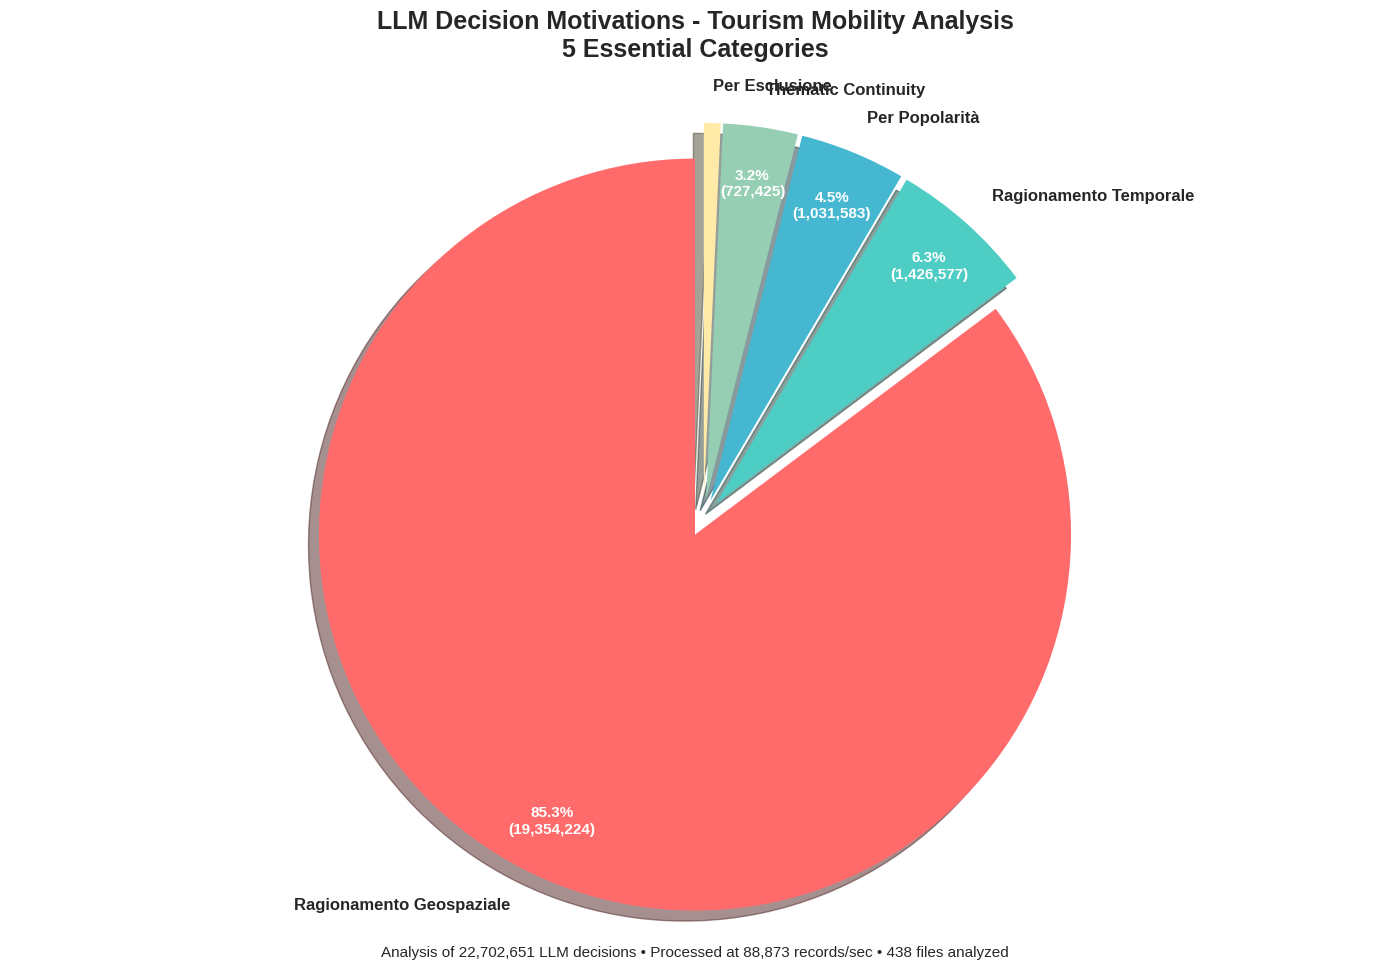


📊 LLM MOTIVATION CATEGORIES (5 Essential):
   1. Ragionamento Geospaziale      :  53.4% (12,130,390 records)
   2. Ragionamento Temporale        :   3.9% (894,117 records)
   3. Per Popolarità                :   2.8% (646,552 records)
   4. Thematic Continuity           :   2.0% (455,919 records)
   5. Per Esclusione                :   0.4% (102,061 records)

🎯 ANALYSIS SUMMARY:
   Total decisions analyzed: 22,702,651
   Processing rate: 88,873 records/second
   Categories identified: 5

✅ 5-CATEGORY ANALYSIS COMPLETED!
📊 Clean and focused motivation analysis
🎯 Essential categories only: Esclusione, Geospaziale, Temporale, Popolarità, Thematic


In [20]:
# CLEAN 5-CATEGORY PIE CHART VISUALIZATION
def create_clean_pie_chart(df: pd.DataFrame, results: Dict) -> None:
    """Create a clean, professional pie chart with 5 essential categories"""
    
    # Setup
    plt.figure(figsize=(14, 10))
    
    # Take all categories (should be max 5 + unknown)
    categories = df[df['category'] != 'unknown'] if 'unknown' in df['category'].values else df
    
    # Prepare data
    labels = categories['category'].tolist()
    sizes = categories['percentage'].tolist()
    
    # Clean color scheme for 5 categories
    colors = [
        '#FF6B6B',  # Coral Red - Per Esclusione
        '#4ECDC4',  # Teal - Ragionamento Geospaziale  
        '#45B7D1',  # Sky Blue - Ragionamento Temporale
        '#96CEB4',  # Mint Green - Per Popolarità
        '#FFEAA7'   # Yellow - Thematic Continuity
    ]
    
    # Ensure we have enough colors
    while len(colors) < len(labels):
        colors.append('#DDA0DD')  # Plum for extras
    
    # Create clean pie chart
    wedges, texts, autotexts = plt.pie(
        sizes, 
        labels=labels,
        colors=colors[:len(labels)],
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*results["total_records"]):,})' if pct > 1 else '',
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'},
        pctdistance=0.85,
        explode=[0.05] * len(labels),  # Small uniform explosion
        shadow=True
    )
    
    # Enhance text properties
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(11)
    
    # Clean title
    plt.title(
        'LLM Decision Motivations - Tourism Mobility Analysis\n5 Essential Categories',
        fontsize=18, 
        weight='bold', 
        pad=20
    )
    
    plt.suptitle(
        f'Analysis of {results["total_records"]:,} LLM decisions • '
        f'Processed at {results["processing_rate"]:,.0f} records/sec • '
        f'{results["files_processed"]} files analyzed',
        fontsize=11,
        y=0.02
    )
    
    # Equal aspect ratio for perfect circle
    plt.axis('equal')
    
    # Tight layout
    plt.tight_layout()
    
    # Save chart
    output_path = Path('./motivation_pie_chart_5_categories.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"💾 Chart saved to: {output_path}")
    
    plt.show()
    
    # Print clean summary
    print(f"\n📊 LLM MOTIVATION CATEGORIES (5 Essential):")
    for i, row in categories.iterrows():
        print(f"   {i+1}. {row['category']:30s}: {row['percentage']:5.1f}% ({row['count']:,} records)")
    
    print(f"\n🎯 ANALYSIS SUMMARY:")
    print(f"   Total decisions analyzed: {results['total_records']:,}")
    print(f"   Processing rate: {results['processing_rate']:,.0f} records/second")
    print(f"   Categories identified: {len(categories)}")

# Execute visualization only if we have data
if 'motivation_df' in locals() and not motivation_df.empty:
    print(f"\n🎨 Creating clean 5-category pie chart...")
    create_clean_pie_chart(motivation_df, analysis_results)
    
    print(f"\n✅ 5-CATEGORY ANALYSIS COMPLETED!")
    print(f"📊 Clean and focused motivation analysis")
    print(f"🎯 Essential categories only: Esclusione, Geospaziale, Temporale, Popolarità, Thematic")
else:
    print("\n❌ No data available for visualization")
    print("Please run the analysis cell successfully first")

In [21]:
# CSV EXPORT FOR CANVA INTEGRATION
def export_chart_data_for_canva(df: pd.DataFrame, results: Dict) -> None:
    """Export chart data to CSV format optimized for Canva import"""
    
    if df.empty:
        print("❌ No data to export")
        return
    
    # Prepare export data
    export_data = []
    
    # Filter out unknown categories for clean export
    categories = df[df['category'] != 'unknown'] if 'unknown' in df['category'].values else df
    
    for _, row in categories.iterrows():
        export_data.append({
            'Category': row['category'],
            'Percentage': f"{row['percentage']:.1f}%",
            'Count': f"{row['count']:,}",
            'Records': row['count'],
            'Percentage_Numeric': round(row['percentage'], 1)
        })
    
    # Create export DataFrame
    export_df = pd.DataFrame(export_data)
    
    # Sort by percentage (descending)
    export_df = export_df.sort_values('Percentage_Numeric', ascending=False)
    
    # Export to CSV
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = Path(f'./motivation_chart_data_canva_{timestamp}.csv')
    
    export_df.to_csv(csv_path, index=False, encoding='utf-8')
    
    # Create simplified version for Canva (just category and percentage)
    simple_export = export_df[['Category', 'Percentage_Numeric']].copy()
    simple_export.columns = ['Category', 'Percentage']
    
    simple_csv_path = Path(f'./motivation_chart_simple_canva_{timestamp}.csv')
    simple_export.to_csv(simple_csv_path, index=False, encoding='utf-8')
    
    # Export metadata file
    metadata = {
        'export_timestamp': timestamp,
        'total_records': results['total_records'],
        'processing_rate': f"{results['processing_rate']:,.0f} records/sec",
        'files_processed': results['files_processed'],
        'categories_count': len(categories),
        'analysis_date': datetime.now().isoformat()
    }
    
    metadata_df = pd.DataFrame([metadata])
    metadata_path = Path(f'./motivation_analysis_metadata_{timestamp}.csv')
    metadata_df.to_csv(metadata_path, index=False, encoding='utf-8')
    
    print(f"📊 CSV EXPORT COMPLETED!")
    print(f"💾 Detailed data: {csv_path}")
    print(f"💾 Simple data for Canva: {simple_csv_path}")
    print(f"💾 Analysis metadata: {metadata_path}")
    print(f"\\n📋 EXPORT SUMMARY:")
    print(export_df.to_string(index=False))
    print(f"\\n🎨 CANVA IMPORT GUIDE:")
    print(f"1. Use '{simple_csv_path}' for pie chart import in Canva")
    print(f"2. Category column = Labels, Percentage column = Values")
    print(f"3. Total records analyzed: {results['total_records']:,}")

# Execute export if data is available
if 'motivation_df' in locals() and not motivation_df.empty and 'analysis_results' in locals():
    print(f"📤 Exporting chart data for Canva integration...")
    export_chart_data_for_canva(motivation_df, analysis_results)
else:
    print("❌ No analysis data available for export")
    print("Please run the analysis cells first")

📤 Exporting chart data for Canva integration...
📊 CSV EXPORT COMPLETED!
💾 Detailed data: motivation_chart_data_canva_20250927_182424.csv
💾 Simple data for Canva: motivation_chart_simple_canva_20250927_182424.csv
💾 Analysis metadata: motivation_analysis_metadata_20250927_182424.csv
\n📋 EXPORT SUMMARY:
                Category Percentage      Count  Records  Percentage_Numeric
Ragionamento Geospaziale      53.4% 12,130,390 12130390                53.4
  Ragionamento Temporale       3.9%    894,117   894117                 3.9
          Per Popolarità       2.8%    646,552   646552                 2.8
     Thematic Continuity       2.0%    455,919   455919                 2.0
          Per Esclusione       0.4%    102,061   102061                 0.4
\n🎨 CANVA IMPORT GUIDE:
1. Use 'motivation_chart_simple_canva_20250927_182424.csv' for pie chart import in Canva
2. Category column = Labels, Percentage column = Values
3. Total records analyzed: 22,702,651
